# GeoPlan: Toronto Public EV-Charging Site Selection

This notebook builds the deterministic geospatial site-selection
workflow used by GeoPlan Agents.

The analysis combines Green P and TTC parking facilities with
population, traffic, transit, public-destination, charger-coverage,
feasibility, and equity indicators. It produces ranked candidate
locations, a spatially separated recommendation sequence, maps, and
compact outputs for the agent layer.

Raw downloaded files are not stored in this repository. Prepare them
using [`data/DATA_GUIDE.md`](../data/DATA_GUIDE.md) before running
the notebook.

Run Jupyter from the repository root so all relative paths resolve
consistently.


In [1]:
from pathlib import Path
from collections import Counter
import io
import json
import random
import warnings
import zipfile

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import requests

from IPython.display import display
from shapely.geometry import Point
from shapely.ops import unary_union
from sklearn.cluster import DBSCAN

warnings.filterwarnings("ignore")


In [2]:
PROJECT_ROOT = Path.cwd().resolve()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    OUTPUT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


## 0. Project paths and local inputs

The notebook expects the repository to be opened from its root
directory. Local source files belong in `data/raw/`; generated
layers and reports are written to `data/processed/` and `outputs/`.

Required filenames and preparation notes are documented in
[`data/DATA_GUIDE.md`](../data/DATA_GUIDE.md).


In [3]:
CONFIG = {
    "city": "Toronto",
    "project_type": "public_ev_charging",
    "number_of_recommendations": 20,
    "analysis_crs": "EPSG:26917",
    "display_crs": "EPSG:4326",
    "distance_units": "metres",
    "buffer_distances_m": [500, 1000, 2000, 5000],
    "existing_charger_exclusion_m": 100,
    "minimum_selected_site_separation_m": 1500,
    "service_radius_m": 1000,
    "category_weights": {
        "demand": 0.30,
        "coverage": 0.25,
        "accessibility": 0.20,
        "feasibility": 0.15,
        "equity": 0.10,
    },
}

CONFIG


{'city': 'Toronto',
 'project_type': 'public_ev_charging',
 'number_of_recommendations': 20,
 'analysis_crs': 'EPSG:26917',
 'display_crs': 'EPSG:4326',
 'distance_units': 'metres',
 'buffer_distances_m': [500, 1000, 2000, 5000],
 'existing_charger_exclusion_m': 100,
 'minimum_selected_site_separation_m': 1500,
 'service_radius_m': 1000,
 'category_weights': {'demand': 0.3,
  'coverage': 0.25,
  'accessibility': 0.2,
  'feasibility': 0.15,
  'equity': 0.1}}


### Configuration parameters

| Parameter | Value | Meaning |
|---|---:|---|
| `number_of_recommendations` | 20 | Maximum number of recommended sites |
| `existing_charger_exclusion_m` | 100 m | Excludes candidates extremely close to known supply |
| `minimum_selected_site_separation_m` | 1,500 m | Prevents recommended sites from clustering |
| `service_radius_m` | 1,000 m | Defines the prototype charger service area |
| `buffer_distances_m` | 500, 1,000, 2,000, 5,000 m | Standard analysis distances |
| `analysis_crs` | EPSG:26917 | Metric CRS for Toronto-area spatial calculations |
| `display_crs` | EPSG:4326 | Longitude/latitude CRS for web maps |

Changing these values changes the planning interpretation. They should be
treated as scenario parameters rather than universal constants.



# Deterministic geospatial workflow

This section contains all calculations required before introducing LLM agents.

## Separation of responsibilities

**Python and GIS libraries**

- retrieve and clean spatial data;
- transform coordinate reference systems;
- calculate distances, buffers, overlays, counts, and weighted averages;
- normalize features and calculate scores;
- enforce exclusions and spatial-separation rules;
- generate maps and machine-readable outputs.

**Future LlamaIndex agents**

- read compact candidate summaries;
- compare objectives and planning scenarios;
- explain why locations were selected;
- identify data limitations and unresolved constraints;
- produce decision memos and stakeholder-facing narratives.

Raw Census polygons, traffic records, and road-network geometries should not be
placed directly in an LLM prompt.

## Workflow stages

1. shared GIS helper functions;
2. existing charger inventory;
3. Green P and TTC parking candidates;
4. data-quality checks;
5. Toronto study-area boundary;
6. optional supplemental charger inventory;
7. baseline coverage and capacity indicators;
8. Census demand indicators;
9. traffic indicators;
10. optional road-network indicators;
11. transit and public-destination indicators;
12. parking-feasibility indicators;
13. equity and service-gap indicators;
14. constraints and exclusions;
15. normalized category scores;
16. deterministic overall score;
17. sequential spatial selection;
18. marginal-population selection;
19. planning scenarios;
20. Monte Carlo weight sensitivity;
21. validation against simple baselines;
22. final maps and plots;
23. agent-ready exports.



## Optional dependencies

The core workflow uses Pandas, GeoPandas, NumPy, Shapely, scikit-learn,
Requests, Matplotlib, and Folium.

```bash
pip install pandas geopandas numpy shapely scikit-learn requests \
            matplotlib folium pyogrio
```

`osmnx` is optional. It is required only when the road-network section is
enabled:

```bash
pip install osmnx
```

Keeping the road download optional makes the notebook faster and reduces
dependency problems. When road features are unavailable, the normalization
functions assign a neutral value rather than automatically rewarding or
penalizing every candidate.



## 1. Shared helper functions

This section defines reusable functions used throughout the notebook.

### Toronto Open Data helpers

`get_ckan_package`, `resources_table`, and `load_first_geojson` query Toronto's
CKAN catalogue, list available resources, and load a usable GeoJSON resource.
The resource table is displayed so the selected source remains transparent.

### Coordinate-system handling

Spatial calculations use:

- **EPSG:4326** for display and web maps;
- **EPSG:26917** for distance, area, and buffer calculations in metres.

Distance and area calculations should not be performed directly on geographic
longitude/latitude coordinates. `ensure_projected` standardizes layers to the
analysis CRS before spatial operations.

### Geometry cleaning

`clean_points`:

1. converts data to the display CRS;
2. explodes multipart records;
3. removes missing, empty, and invalid geometries;
4. retains point geometries only.

`unique_coordinate_points` removes duplicate locations after rounding
coordinates to six decimal places.

### Normalization

Continuous indicators with different units are converted to a common
0-to-1 scale:

$$
x_i^{*} = \frac{x_i-\min(x)}{\max(x)-\min(x)}
$$

For criteria where a smaller value is preferred, inverse normalization is used:

$$
x_{i,\mathrm{inverse}}^{*}=1-x_i^{*}
$$

Missing values are replaced with the variable median before normalization.
When an entire variable is missing or constant, a neutral score of `0.5` is
returned.

### General spatial utilities

- `nearest_distance` calculates the nearest target distance.
- `add_point_count` counts target points inside a candidate buffer.
- `average_pairwise_distance_m` measures geographic dispersion among selected
  sites.


In [4]:
CKAN_PACKAGE_SHOW_URL = (
    "https://ckan0.cf.opendata.inter.prod-toronto.ca/"
    "api/3/action/package_show"
)


def get_ckan_package(package_id):
    response = requests.get(
        CKAN_PACKAGE_SHOW_URL,
        params={"id": package_id},
        timeout=60,
    )
    response.raise_for_status()
    payload = response.json()
    if not payload.get("success"):
        raise RuntimeError(f"CKAN request failed for {package_id}")
    return payload["result"]


def resources_table(package):
    return pd.DataFrame(
        [
            {
                "resource_index": i,
                "name": r.get("name"),
                "format": r.get("format"),
                "datastore_active": r.get("datastore_active"),
                "last_modified": r.get("last_modified"),
                "url": r.get("url"),
            }
            for i, r in enumerate(package.get("resources", []))
        ]
    )


def load_first_geojson(resources):
    options = resources[
        resources["format"].fillna("").str.upper() == "GEOJSON"
    ].copy()

    if options.empty:
        raise RuntimeError("No GeoJSON resource was found.")

    options["_store"] = options[
        "datastore_active"
    ].fillna(False).astype(int)

    options = options.sort_values(
        ["_store", "last_modified"],
        ascending=[True, False],
        na_position="last",
    )

    errors = {}
    for _, resource in options.iterrows():
        try:
            data = gpd.read_file(resource["url"])
            if data.empty:
                raise ValueError("Empty resource")
            return data, resource
        except Exception as exc:
            errors[int(resource["resource_index"])] = str(exc)

    raise RuntimeError(f"Could not load GeoJSON resources: {errors}")


def min_max_normalize(series, neutral=0.5):
    values = pd.to_numeric(series, errors="coerce")

    if values.notna().sum() == 0:
        return pd.Series(neutral, index=series.index, dtype=float)

    values = values.fillna(values.median())
    lower = values.min()
    upper = values.max()

    if np.isclose(lower, upper):
        return pd.Series(neutral, index=series.index, dtype=float)

    return (values - lower) / (upper - lower)


def inverse_normalize(series, neutral=0.5):
    return 1.0 - min_max_normalize(series, neutral)


def ensure_projected(gdf):
    if gdf.crs is None:
        raise ValueError("GeoDataFrame has no CRS.")
    return gdf.to_crs(CONFIG["analysis_crs"])


def clean_points(gdf):
    if gdf.crs is None:
        raise ValueError("GeoDataFrame has no CRS.")

    result = gdf.to_crs(
        CONFIG["display_crs"]
    ).explode(index_parts=False).reset_index(drop=True)

    result = result[
        result.geometry.notna()
        & ~result.geometry.is_empty
        & result.geometry.is_valid
        & (result.geometry.geom_type == "Point")
    ].copy()

    return result.reset_index(drop=True)


def unique_coordinate_points(gdf, decimals=6):
    work = gdf.to_crs(CONFIG["display_crs"]).copy()
    work["_x_key"] = work.geometry.x.round(decimals)
    work["_y_key"] = work.geometry.y.round(decimals)

    work = work.drop_duplicates(
        subset=["_x_key", "_y_key"]
    ).drop(columns=["_x_key", "_y_key"])

    return work.reset_index(drop=True)


def nearest_distance(source, target, output_column):
    source_p = ensure_projected(source).copy()
    target_p = ensure_projected(target)

    if target_p.empty:
        source_p[output_column] = np.nan
        return source_p

    joined = gpd.sjoin_nearest(
        source_p,
        target_p[["geometry"]],
        how="left",
        distance_col=output_column,
    ).drop(columns=["index_right"], errors="ignore")

    if "candidate_id" in joined.columns:
        joined = (
            joined.sort_values(output_column)
            .drop_duplicates("candidate_id")
        )
    else:
        joined = joined.loc[
            ~joined.index.duplicated(keep="first")
        ]

    return joined.reset_index(drop=True)


def add_point_count(candidates, points, radius_m, output_column):
    result = ensure_projected(candidates).copy()
    targets = list(ensure_projected(points).geometry.dropna())

    result[output_column] = [
        sum(geometry.distance(point) <= radius_m for point in targets)
        for geometry in result.geometry
    ]
    return result


def find_column(columns, keyword_groups):
    normalized = {
        column: str(column).lower().replace(" ", "_")
        for column in columns
    }

    for keywords in keyword_groups:
        for original, candidate in normalized.items():
            if all(keyword in candidate for keyword in keywords):
                return original
    return None


def average_pairwise_distance_m(gdf):
    geometries = list(ensure_projected(gdf).geometry)
    distances = [
        geometries[i].distance(geometries[j])
        for i in range(len(geometries))
        for j in range(i + 1, len(geometries))
    ]
    return float(np.mean(distances)) if distances else np.nan



## 2. Existing city-operated EV charger inventory

The notebook retrieves Toronto's City-operated EV-charger dataset through the
Open Data CKAN API.

### Processing steps

1. list all available package resources;
2. select a readable GeoJSON resource;
3. explode multipart geometry when necessary;
4. retain valid point locations;
5. remove duplicate coordinates;
6. project the result to EPSG:26917;
7. save the cleaned inventory to:

```text
data/processed/existing_city_ev_chargers.geojson
```

This inventory establishes the **current supply network** used to calculate
coverage gaps. Its count represents unique locations in the City-operated
dataset, not necessarily every publicly accessible charger from all operators.


In [5]:
EV_CHARGER_PACKAGE_ID = (
    "city-operated-electric-vehicle-charging-station-map"
)

ev_package = get_ckan_package(EV_CHARGER_PACKAGE_ID)
ev_resources = resources_table(ev_package)

pd.set_option("display.max_colwidth", None)
display(
    ev_resources[
        [
            "resource_index",
            "name",
            "format",
            "datastore_active",
            "last_modified",
        ]
    ]
)

chargers_raw, selected_ev_resource = load_first_geojson(
    ev_resources
)

chargers_points = clean_points(chargers_raw)
chargers_unique_locations = unique_coordinate_points(
    chargers_points
)
chargers_unique_projected = ensure_projected(
    chargers_unique_locations
)

print("Selected resource:", selected_ev_resource["name"])
print("Raw rows:", len(chargers_raw))
print("Point rows after explode:", len(chargers_points))
print("Unique charger locations:", len(chargers_unique_locations))

charger_path = (
    PROCESSED_DATA_DIR / "existing_city_ev_chargers.geojson"
)
chargers_unique_locations.to_file(
    charger_path,
    driver="GeoJSON",
)
print("Saved:", charger_path.resolve())


,resource_index,name,format,datastore_active,last_modified
0,0,City Operated Electric Vehicle Charging Station Map,GeoJSON,True,None
1,1,City Operated Electric Vehicle Charging Station Map - 4326.csv,CSV,False,2026-02-20T21:34:18.174026
2,2,City Operated Electric Vehicle Charging Station Map - 4326.zip,SHP,False,2026-02-20T21:34:19.195430
3,3,City Operated Electric Vehicle Charging Station Map - 4326.gpkg,gpkg,False,2026-02-20T21:34:20.149250
4,4,City Operated Electric Vehicle Charging Station Map - 4326.geojson,GeoJSON,False,2026-02-20T21:34:21.092264
5,5,City Operated Electric Vehicle Charging Station Map - 2952.csv,CSV,False,2026-02-20T21:34:21.988509
6,6,City Operated Electric Vehicle Charging Station Map - 2952.zip,SHP,False,2026-02-20T21:34:22.917110
7,7,City Operated Electric Vehicle Charging Station Map - 2952.gpkg,gpkg,False,2026-02-20T21:34:23.735656


Selected resource: City Operated Electric Vehicle Charging Station Map - 4326.geojson
Raw rows: 82
Point rows after explode: 82
Unique charger locations: 79
Saved: /Users/miladsaeedi/Desktop/Daily_Work_load/Projects_for_CV/Geospatial_site_selection/data/processed/existing_city_ev_chargers.geojson



### Charger-inventory interpretation

The output is a count of unique geographic locations, not a count of individual
plugs or connectors. Multiple connectors at one site may still be represented
by one point. The City-operated inventory may also omit public chargers managed
by other organizations.



## 3. Green P and TTC parking facilities as candidate sites

Green P and TTC-associated parking facilities form the candidate universe.
Parking facilities are useful screening locations because they already support
vehicle access and provide capacity information.

### Cleaning logic

The code:

- retrieves the `green-p-parking-2019` resource;
- normalizes the nested JSON response;
- retains identifiers, address, coordinates, facility type, TTC status,
  construction status, capacity, height, bicycle racks, rates, and permit
  information when available;
- converts numeric fields safely;
- removes invalid Toronto-area coordinates;
- removes facilities marked as under construction;
- creates a stable `candidate_id`;
- removes duplicate coordinates.

### Candidate-universe limitation

A location outside the Green P/TTC dataset cannot be recommended by this
notebook, even if it may be suitable in reality. The model therefore answers:

> Which available Green P or TTC parking facilities are most suitable?

It does not answer:

> Which parcel anywhere in Toronto is globally optimal?


In [6]:
GREEN_P_PACKAGE_ID = "green-p-parking"

green_p_package = get_ckan_package(GREEN_P_PACKAGE_ID)
green_p_resources = resources_table(green_p_package)

display(
    green_p_resources[
        [
            "resource_index",
            "name",
            "format",
            "last_modified",
            "url",
        ]
    ]
)

resource_rows = green_p_resources[
    green_p_resources["name"] == "green-p-parking-2019"
]

if resource_rows.empty:
    raise RuntimeError("green-p-parking-2019 was not found.")

green_p_url = resource_rows.iloc[0]["url"]
response = requests.get(green_p_url, timeout=60)
response.raise_for_status()
green_p_json = response.json()

green_p_raw = pd.json_normalize(
    green_p_json["carparks"]
)

candidate_columns = [
    "id",
    "address",
    "lat",
    "lng",
    "carpark_type",
    "carpark_type_str",
    "is_ttc",
    "is_under_construction",
    "capacity",
    "max_height",
    "bike_racks",
    "rate_half_hour",
    "monthly_permit_status",
]

green_p_clean = green_p_raw[
    [c for c in candidate_columns if c in green_p_raw.columns]
].copy()

for column in [
    "lat",
    "lng",
    "capacity",
    "max_height",
    "rate_half_hour",
]:
    if column in green_p_clean:
        green_p_clean[column] = pd.to_numeric(
            green_p_clean[column],
            errors="coerce",
        )

green_p_clean = green_p_clean[
    green_p_clean["lat"].between(43.0, 44.5)
    & green_p_clean["lng"].between(-80.5, -78.0)
].copy()

if "is_under_construction" in green_p_clean:
    under_construction = (
        green_p_clean["is_under_construction"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )
    green_p_clean = green_p_clean[
        ~under_construction
    ].copy()

green_p_candidates = gpd.GeoDataFrame(
    green_p_clean,
    geometry=gpd.points_from_xy(
        green_p_clean["lng"],
        green_p_clean["lat"],
    ),
    crs=CONFIG["display_crs"],
).reset_index(drop=True)

green_p_candidates["candidate_id"] = (
    "green_p_" + green_p_candidates["id"].astype(str)
)

green_p_candidates = unique_coordinate_points(
    green_p_candidates
)

print("Candidate parking facilities:", len(green_p_candidates))
display(green_p_candidates.head())


,resource_index,name,format,last_modified,url
0,0,green-p-parking-2019,JSON,2019-07-23T17:30:48.974101,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/b66466c3-69c8-4825-9c8b-04b270069193/resource/8549d588-30b0-482e-b872-b21beefdda22/download/green-p-parking-2019.json
1,1,green-p-parking-2015,JSON,2019-07-23T17:30:49.830765,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/b66466c3-69c8-4825-9c8b-04b270069193/resource/31abc7f3-0796-42d9-9ed2-22d216ae338b/download/green-p-parking-2015.json
2,2,green-p-parking-readme,XLS,2019-07-23T17:30:50.666065,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/b66466c3-69c8-4825-9c8b-04b270069193/resource/dba88efd-f692-4ce2-ae77-d0ec3f08bd21/download/green-p-parking-readme.xls


Candidate parking facilities: 248


,id,address,lat,lng,carpark_type,carpark_type_str,is_ttc,is_under_construction,capacity,max_height,bike_racks,rate_half_hour,monthly_permit_status,geometry,candidate_id
0,1,20 Charles Street East,43.669282,-79.385289,garage,Garage,False,False,641,2.00,available,2.5,not_available,POINT (-79.38529 43.66928),green_p_1
1,3,13 Isabella Street,43.667577,-79.384707,surface,Surface,False,False,33,0.00,not available,3.0,not_available,POINT (-79.38471 43.66758),green_p_3
2,5,15 Wellesley Street East,43.664837,-79.383591,surface,Surface,False,False,135,0.00,available,3.0,not_available,POINT (-79.38359 43.66484),green_p_5
3,11,21 Pleasant Blvd.,43.687092,-79.392850,garage,Garage,False,False,557,1.90,available,3.0,not_available,POINT (-79.39285 43.68709),green_p_11
4,12,30 Alvin Avenue,43.689191,-79.392700,surface,Surface,False,False,188,2.67,available,3.5,not_available,POINT (-79.3927 43.68919),green_p_12



## 4. Data-quality checks

Before feature engineering, the notebook summarizes the quality of the charger
and candidate layers.

For each GeoDataFrame it reports:

- number of rows and columns;
- missing geometries;
- empty geometries;
- invalid geometries;
- geometry-type distribution;
- coordinate reference system.

A separate missing-value table is produced for candidate attributes. These
checks are important because missing capacity, malformed points, and incorrect
CRS definitions can materially affect distances and rankings.


In [7]:
def data_quality_row(name, gdf):
    return {
        "dataset": name,
        "rows": len(gdf),
        "columns": len(gdf.columns),
        "missing_geometry": int(gdf.geometry.isna().sum()),
        "empty_geometry": int(gdf.geometry.is_empty.sum()),
        "invalid_geometry": int((~gdf.geometry.is_valid).sum()),
        "geometry_types": gdf.geometry.geom_type.value_counts().to_dict(),
        "crs": str(gdf.crs),
    }


data_quality_summary = pd.DataFrame(
    [
        data_quality_row(
            "Existing city chargers",
            chargers_unique_locations,
        ),
        data_quality_row(
            "Candidate parking facilities",
            green_p_candidates,
        ),
    ]
)

display(data_quality_summary)

print("Candidate missing values:")
display(
    green_p_candidates.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)


,dataset,rows,columns,missing_geometry,empty_geometry,invalid_geometry,geometry_types,crs
0,Existing city chargers,79,7,0,0,0,{'Point': 79},EPSG:4326
1,Candidate parking facilities,248,15,0,0,0,{'Point': 248},EPSG:4326


Candidate missing values:


,missing_values
max_height,60
id,0
address,0
lat,0
lng,0
carpark_type,0
carpark_type_str,0
is_ttc,0
is_under_construction,0
capacity,0



## 5. Toronto study-area boundary

The study boundary is created by dissolving the prepared 2021 Census
dissemination-area polygons. If the local file is unavailable, Toronto City
Wards are used as a fallback.

All candidate points are projected to EPSG:26917 and retained only when they
fall within the Toronto polygon.

This step prevents nearby facilities outside the municipality from entering the
candidate pool and establishes a consistent geographic scope for all later
analyses.


In [8]:
LOCAL_BOUNDARY_FILE = (
    RAW_DATA_DIR / "census_da_boundaries.geojson"
)

boundary_raw = gpd.read_file(
    LOCAL_BOUNDARY_FILE
)

if boundary_raw.crs is None:
    raise ValueError(
        "The Census boundary file has no CRS."
    )

boundary_projected = ensure_projected(
    boundary_raw
)

valid_boundary_geometry = (
    boundary_projected.geometry
    .dropna()
)

if valid_boundary_geometry.empty:
    raise ValueError(
        "The Census boundary file contains no geometry."
    )

toronto_boundary = gpd.GeoDataFrame(
    {"study_area": ["Toronto"]},
    geometry=[
        valid_boundary_geometry.union_all()
    ],
    crs=CONFIG["analysis_crs"],
)

candidate_sites_all = ensure_projected(
    green_p_candidates
)

candidate_sites_all = gpd.sjoin(
    candidate_sites_all,
    toronto_boundary[["geometry"]],
    how="inner",
    predicate="within",
).drop(
    columns=["index_right"],
    errors="ignore",
).reset_index(drop=True)

if candidate_sites_all.empty:
    raise RuntimeError(
        "No Green P candidates fall inside the Toronto boundary."
    )



## 6. Supplemental public charger inventory

The City-operated inventory may omit chargers managed by private or commercial
operators. The notebook can optionally read:

```text
data/raw/additional_public_chargers.geojson
```

When the file is absent, the workflow continues without error.

### Deduplication

City and supplemental records are combined and clustered with DBSCAN using a
30-metre threshold. Nearby records are treated as descriptions of the same
charging site.

For each cluster, the workflow retains one representative geometry and records:

- a generated charger-site ID;
- all represented data sources;
- the number of merged source records.

The resulting layer, `all_known_public_chargers`, is the supply network used by
coverage calculations.


In [9]:
ADDITIONAL_CHARGER_FILE = (
    RAW_DATA_DIR / "additional_public_chargers.geojson"
)
DEDUPLICATION_DISTANCE_M = 30

city_supply = chargers_unique_projected.copy()
city_supply["data_source"] = "Toronto city-operated"
charger_sources = [city_supply]

if ADDITIONAL_CHARGER_FILE.exists():
    supplemental = gpd.read_file(
        ADDITIONAL_CHARGER_FILE
    )
    supplemental = ensure_projected(
        clean_points(supplemental)
    )
    supplemental["data_source"] = (
        "Supplemental public charger inventory"
    )
    charger_sources.append(supplemental)

combined_supply = gpd.GeoDataFrame(
    pd.concat(charger_sources, ignore_index=True),
    geometry="geometry",
    crs=CONFIG["analysis_crs"],
)

coordinates = np.column_stack(
    [
        combined_supply.geometry.x,
        combined_supply.geometry.y,
    ]
)

combined_supply["_cluster"] = DBSCAN(
    eps=DEDUPLICATION_DISTANCE_M,
    min_samples=1,
).fit_predict(coordinates)

records = []
for cluster_id, group in combined_supply.groupby("_cluster"):
    row = group.iloc[0].copy()
    row["charger_site_id"] = f"charger_{cluster_id:04d}"
    row["data_source"] = "; ".join(
        sorted(group["data_source"].unique())
    )
    row["merged_record_count"] = len(group)
    records.append(row)

all_known_public_chargers = gpd.GeoDataFrame(
    records,
    geometry="geometry",
    crs=CONFIG["analysis_crs"],
).reset_index(drop=True)

print(
    "Deduplicated known public charger locations:",
    len(all_known_public_chargers),
)


Deduplicated known public charger locations: 77



## 7. Baseline candidate features

This stage establishes simple coverage and facility-size indicators before the
full multi-criteria model.

### Coverage indicators

For every candidate, the notebook calculates:

- distance to the nearest known charger;
- number of existing chargers within 1 km;
- number of existing chargers within 2 km.

Candidates within the configured exclusion distance—100 metres by default—are
removed because placing another site extremely close to known supply is unlikely
to improve geographic coverage.

### Capacity treatment

Parking capacity is converted to numeric form. Missing values are flagged in
`capacity_missing` and replaced with the candidate median in `capacity_filled`.
The flag remains available so downstream reviewers can distinguish observed
from imputed capacity.

### Exploratory baseline score

The initial score is:

$$
S_{\mathrm{baseline}}
=0.60S_{\mathrm{coverage-distance}}
+0.40S_{\mathrm{capacity}}
$$

Capacity is log-transformed before normalization to reduce the influence of
very large facilities. This score is exploratory; the final recommendation uses
the more complete framework developed later.


In [10]:
candidate_sites = nearest_distance(
    candidate_sites_all,
    all_known_public_chargers,
    "distance_to_nearest_charger_m",
)

candidate_sites["capacity"] = pd.to_numeric(
    candidate_sites["capacity"],
    errors="coerce",
)
candidate_sites["capacity_missing"] = (
    candidate_sites["capacity"].isna()
)
candidate_sites["capacity_filled"] = (
    candidate_sites["capacity"].fillna(
        candidate_sites["capacity"].median()
    )
)

candidate_sites = candidate_sites[
    candidate_sites["distance_to_nearest_charger_m"]
    > CONFIG["existing_charger_exclusion_m"]
].copy().reset_index(drop=True)

candidate_sites = add_point_count(
    candidate_sites,
    all_known_public_chargers,
    1000,
    "existing_chargers_1000m",
)
candidate_sites = add_point_count(
    candidate_sites,
    all_known_public_chargers,
    2000,
    "existing_chargers_2000m",
)

candidate_sites["baseline_coverage_score"] = (
    min_max_normalize(
        candidate_sites["distance_to_nearest_charger_m"]
    )
)
candidate_sites["baseline_capacity_score"] = (
    min_max_normalize(
        np.log1p(candidate_sites["capacity_filled"])
    )
)
candidate_sites["baseline_score"] = (
    0.60 * candidate_sites["baseline_coverage_score"]
    + 0.40 * candidate_sites["baseline_capacity_score"]
)

display(
    candidate_sites[
        [
            "candidate_id",
            "address",
            "capacity_filled",
            "distance_to_nearest_charger_m",
            "existing_chargers_2000m",
            "baseline_score",
        ]
    ].sort_values(
        "baseline_score",
        ascending=False,
    ).head(15)
)


,candidate_id,address,capacity_filled,distance_to_nearest_charger_m,existing_chargers_2000m,baseline_score
212,green_p_700,101 Grangeway Avenue,261,10141.587715,0,0.788383
213,green_p_706,284 Milner Avenue,103,11295.257185,0,0.783268
211,green_p_710,100 Grangeway Avenue,214,10033.701714,0,0.768331
214,green_p_707,1530 Markham Road - minor capital repairs onsite,24,11334.211766,0,0.682339
206,green_p_821,Kennedy South Lot -155 Transway Cres,673,5971.341673,0,0.633805
209,green_p_818,Lawrence East Lot - Near 2450 Lawrence Ave East,90,7682.226155,0,0.580538
210,green_p_711,158 Borough Drive,16,9615.959336,0,0.562646
207,green_p_826,Kennedy North Service Road - 2450 Eglinton Ave East,199,6177.240326,0,0.557016
200,green_p_811,Wilson Main Lot - 50 Wilson Heights Blvd,885,4069.043847,0,0.551909
199,green_p_822,Warden North Lot - 705 Warden Ave,920,3719.954739,0,0.536054



## 8. Population and household demand

Prepared 2021 Census dissemination-area boundaries are joined to the attribute
table using `DGUID` when possible and `DAUID` as a fallback.

The expected standardized attributes are:

- `population`;
- `households`;
- `apartment_population`;
- `median_income`.

### Area-weighted interpolation

Candidate buffers of 500, 1,000, and 2,000 metres rarely align exactly with
Census polygons. The notebook estimates the amount of a Census variable inside
a buffer using the proportion of each dissemination area that overlaps it:

$$
\widehat{V}_{b}
=
\sum_i
V_i
\left(
\frac{A_{i\cap b}}{A_i}
\right)
$$

where:

- $V_i$ is the value for dissemination area $i$;
- $A_i$ is its total area;
- $A_{i\cap b}$ is its area inside candidate buffer $b$.

This produces buffer-level estimates for population, households, and apartment
population. Median income is calculated as a population-weighted average over
the intersected areas.

### Apartment share

For each radius:

$$
\mathrm{Apartment\ Share}
=
\frac{\mathrm{Estimated\ Apartment\ Population}}
{\mathrm{Estimated\ Total\ Population}}
$$

In the preparation notebook, apartment population is an estimate derived from
apartment dwellings and average household size. It should be interpreted as a
proxy for limited access to private residential charging, not an exact count.


In [11]:

CENSUS_BOUNDARY_FILE = (
    RAW_DATA_DIR / "census_da_boundaries.geojson"
)
CENSUS_ATTRIBUTE_FILE = (
    RAW_DATA_DIR / "census_da_attributes.csv"
)

CENSUS_COLUMN_MAP = {
    "population": "population",
    "households": "households",
    "apartment_population": "apartment_population",
    "median_income": "median_income",
}

boundaries = gpd.read_file(
    CENSUS_BOUNDARY_FILE
)

attributes = pd.read_csv(
    CENSUS_ATTRIBUTE_FILE,
    dtype={
        "DAUID": str,
        "DGUID": str,
    },
)

if boundaries.crs is None:
    raise ValueError(
        "census_da_boundaries.geojson has no CRS."
    )

missing_attribute_columns = [
    source
    for source in CENSUS_COLUMN_MAP.values()
    if source not in attributes.columns
]

if missing_attribute_columns:
    raise KeyError(
        "census_da_attributes.csv is missing: "
        f"{missing_attribute_columns}"
    )

for column in CENSUS_COLUMN_MAP.values():
    attributes[column] = pd.to_numeric(
        attributes[column],
        errors="coerce",
    )

# DGUID is preferred because it identifies both the Census year
# and geography type. DAUID remains the fallback.
if (
    "DGUID" in boundaries.columns
    and "DGUID" in attributes.columns
):
    CENSUS_JOIN_KEY = "DGUID"
else:
    CENSUS_JOIN_KEY = "DAUID"

boundaries[CENSUS_JOIN_KEY] = (
    boundaries[CENSUS_JOIN_KEY]
    .astype(str)
    .str.strip()
)
attributes[CENSUS_JOIN_KEY] = (
    attributes[CENSUS_JOIN_KEY]
    .astype(str)
    .str.strip()
)

selected_attribute_columns = [
    CENSUS_JOIN_KEY,
    *CENSUS_COLUMN_MAP.values(),
]

selected_attributes = (
    attributes[selected_attribute_columns]
    .drop_duplicates(
        subset=[CENSUS_JOIN_KEY]
    )
    .rename(
        columns={
            source: standard
            for standard, source
            in CENSUS_COLUMN_MAP.items()
        }
    )
)

census_areas = boundaries.merge(
    selected_attributes,
    on=CENSUS_JOIN_KEY,
    how="left",
    validate="one_to_one",
)

census_areas = ensure_projected(
    census_areas
)

census_areas = census_areas[
    census_areas.geometry.notna()
    & ~census_areas.geometry.is_empty
].copy()

census_areas["source_area_m2"] = (
    census_areas.geometry.area
)

matched_population = int(
    census_areas["population"].notna().sum()
)

print("Census join key:", CENSUS_JOIN_KEY)
print("Census boundary rows:", len(boundaries))
print("Rows with population attributes:", matched_population)

if matched_population == 0:
    raise RuntimeError(
        "No Census attributes matched the DA boundaries."
    )

display(
    census_areas[
        [
            CENSUS_JOIN_KEY,
            "population",
            "households",
            "apartment_population",
            "median_income",
        ]
    ].head()
)


Census join key: DGUID
Census boundary rows: 3743
Rows with population attributes: 3743


,DGUID,population,households,apartment_population,median_income
0,2021S051235200002,333.0,105.0,64.0,83000.0
1,2021S051235200003,314.0,90.0,70.0,106000.0
2,2021S051235200004,346.0,100.0,86.0,106000.0
3,2021S051235200005,412.0,110.0,186.0,97000.0
4,2021S051235200006,520.0,135.0,193.0,103000.0


In [12]:

def area_weighted_population_features(
    candidates,
    census,
    radii=(500, 1000, 2000),
):
    result = ensure_projected(candidates).copy()
    census = ensure_projected(census).copy()

    required_columns = {
        "population",
        "households",
        "apartment_population",
        "median_income",
        "source_area_m2",
        "geometry",
    }

    missing_columns = (
        required_columns - set(census.columns)
    )
    if missing_columns:
        raise KeyError(
            "Census data are missing: "
            f"{sorted(missing_columns)}"
        )

    census = census[
        census.geometry.notna()
        & ~census.geometry.is_empty
        & (census["source_area_m2"] > 0)
    ].copy()

    for radius in radii:
        buffers = result[
            ["candidate_id", "geometry"]
        ].copy()

        buffers["geometry"] = (
            buffers.geometry.buffer(radius)
        )

        census_columns = [
            column
            for column in [
                "DAUID",
                "DGUID",
                "population",
                "households",
                "apartment_population",
                "median_income",
                "source_area_m2",
                "geometry",
            ]
            if column in census.columns
        ]

        intersections = gpd.overlay(
            census[census_columns],
            buffers,
            how="intersection",
            keep_geom_type=False,
        )

        output_sum_columns = {
            "population": f"population_{radius}m",
            "households": f"households_{radius}m",
            "apartment_population": (
                f"apartment_population_{radius}m"
            ),
        }

        if intersections.empty:
            for output_column in output_sum_columns.values():
                result[output_column] = 0.0

            result[
                f"median_income_{radius}m"
            ] = np.nan
            result[
                f"apartment_share_{radius}m"
            ] = 0.0
            continue

        intersections["fraction"] = (
            intersections.geometry.area
            / intersections["source_area_m2"]
        ).clip(0, 1)

        for source_column in output_sum_columns:
            intersections[
                f"_weighted_{source_column}"
            ] = (
                intersections[source_column]
                * intersections["fraction"]
            )

        grouped = (
            intersections
            .groupby("candidate_id")
            [
                [
                    "_weighted_population",
                    "_weighted_households",
                    "_weighted_apartment_population",
                ]
            ]
            .sum(min_count=1)
            .rename(
                columns={
                    "_weighted_population": (
                        f"population_{radius}m"
                    ),
                    "_weighted_households": (
                        f"households_{radius}m"
                    ),
                    "_weighted_apartment_population": (
                        f"apartment_population_{radius}m"
                    ),
                }
            )
        )

        income_numerator = (
            intersections["median_income"]
            * intersections["_weighted_population"]
        ).groupby(
            intersections["candidate_id"]
        ).sum(min_count=1)

        income_denominator = (
            intersections.groupby(
                "candidate_id"
            )["_weighted_population"].sum()
        )

        grouped[
            f"median_income_{radius}m"
        ] = (
            income_numerator
            / income_denominator.replace(0, np.nan)
        )

        result = result.merge(
            grouped.reset_index(),
            on="candidate_id",
            how="left",
        )

        for output_column in output_sum_columns.values():
            result[output_column] = (
                result[output_column].fillna(0)
            )

        result[
            f"apartment_share_{radius}m"
        ] = (
            result[
                f"apartment_population_{radius}m"
            ]
            / result[
                f"population_{radius}m"
            ].replace(0, np.nan)
        ).clip(0, 1).fillna(0)

    return gpd.GeoDataFrame(
        result,
        geometry="geometry",
        crs=CONFIG["analysis_crs"],
    )


candidate_sites = area_weighted_population_features(
    candidate_sites,
    census_areas,
)

print(
    "Population feature coverage:",
    int(candidate_sites["population_1000m"].notna().sum()),
    "of",
    len(candidate_sites),
)


Population feature coverage: 215 of 215



## 9. Traffic demand

The prepared traffic-count point file is expected to contain the standardized
field `traffic_volume`.

For each candidate, the notebook calculates:

- distance to the nearest traffic-count location;
- number of traffic counters within 1 km;
- inverse-distance-weighted traffic volume within 1 km.

The traffic estimate is:

$$
\widehat{T}_j
=
\frac{\sum_i w_{ij}T_i}{\sum_i w_{ij}},
\qquad
w_{ij}=\frac{1}{d_{ij}+100}
$$

where $T_i$ is observed volume and $d_{ij}$ is the distance in metres from
candidate $j$ to counter $i$. Adding 100 metres prevents an extremely close
counter from receiving an unbounded weight.

### Data-quality label

The nearest-counter distance is translated into a simple quality indicator:

- **high:** at most 250 m;
- **medium:** more than 250 m and at most 750 m;
- **low:** more than 750 m.

This label reflects spatial proximity to observed traffic data, not the
statistical accuracy or temporal representativeness of the count.


In [13]:

TRAFFIC_FILE = (
    RAW_DATA_DIR / "traffic_counts.geojson"
)
TRAFFIC_VOLUME_COLUMN = "traffic_volume"

traffic_counts = gpd.read_file(
    TRAFFIC_FILE
)

if traffic_counts.crs is None:
    raise ValueError(
        "traffic_counts.geojson has no CRS."
    )

traffic_counts = ensure_projected(
    traffic_counts
)

if not traffic_counts.geometry.geom_type.isin(
    ["Point", "MultiPoint"]
).all():
    traffic_counts = traffic_counts.copy()
    traffic_counts["geometry"] = (
        traffic_counts.geometry.centroid
    )

traffic_counts = ensure_projected(
    clean_points(traffic_counts)
)

if TRAFFIC_VOLUME_COLUMN not in traffic_counts.columns:
    alternatives = [
        "traffic_volume_per_hour",
        "total_vehicle",
    ]

    TRAFFIC_VOLUME_COLUMN = next(
        (
            column
            for column in alternatives
            if column in traffic_counts.columns
        ),
        None,
    )

if TRAFFIC_VOLUME_COLUMN is None:
    raise KeyError(
        "No traffic-volume field was found. "
        f"Available columns: {traffic_counts.columns.tolist()}"
    )

traffic_counts[TRAFFIC_VOLUME_COLUMN] = pd.to_numeric(
    traffic_counts[TRAFFIC_VOLUME_COLUMN],
    errors="coerce",
)

traffic_counts = traffic_counts[
    traffic_counts[TRAFFIC_VOLUME_COLUMN].notna()
    & (traffic_counts[TRAFFIC_VOLUME_COLUMN] >= 0)
].copy()

if traffic_counts.empty:
    raise RuntimeError(
        "No valid traffic-count rows remain."
    )

print(
    "Traffic-volume column:",
    TRAFFIC_VOLUME_COLUMN,
)
print("Traffic point rows:", len(traffic_counts))
print(
    "Traffic-volume range:",
    traffic_counts[TRAFFIC_VOLUME_COLUMN].min(),
    "to",
    traffic_counts[TRAFFIC_VOLUME_COLUMN].max(),
)


Traffic-volume column: traffic_volume
Traffic point rows: 6373
Traffic-volume range: 26 to 72545


In [14]:

def add_traffic_features(
    candidates,
    traffic,
    volume_column,
    radius_m=1000,
):
    result = ensure_projected(candidates).copy()
    traffic = ensure_projected(traffic).copy()

    traffic[volume_column] = pd.to_numeric(
        traffic[volume_column],
        errors="coerce",
    )

    traffic = traffic[
        traffic[volume_column].notna()
        & traffic.geometry.notna()
        & ~traffic.geometry.is_empty
    ].copy()

    feature_rows = []

    for _, candidate in result.iterrows():
        distances = traffic.geometry.distance(
            candidate.geometry
        )

        nearest = (
            float(distances.min())
            if not distances.empty
            else np.nan
        )

        nearby_mask = distances <= radius_m
        nearby = traffic.loc[nearby_mask].copy()
        nearby_distances = distances.loc[
            nearby_mask
        ]

        if nearby.empty:
            weighted_volume = np.nan
            counter_count = 0
        else:
            weights = 1.0 / (
                nearby_distances.to_numpy()
                + 100.0
            )

            weighted_volume = float(
                np.average(
                    nearby[volume_column].to_numpy(),
                    weights=weights,
                )
            )
            counter_count = len(nearby)

        feature_rows.append(
            {
                "candidate_id": candidate["candidate_id"],
                "distance_to_traffic_count_m": nearest,
                "traffic_volume_weighted_1000m": (
                    weighted_volume
                ),
                "traffic_counters_1000m": counter_count,
            }
        )

    result = result.merge(
        pd.DataFrame(feature_rows),
        on="candidate_id",
        how="left",
    )

    result["traffic_data_quality"] = pd.cut(
        result["distance_to_traffic_count_m"],
        [-np.inf, 250, 750, np.inf],
        labels=["high", "medium", "low"],
    ).astype("string")

    return gpd.GeoDataFrame(
        result,
        geometry="geometry",
        crs=CONFIG["analysis_crs"],
    )


candidate_sites = add_traffic_features(
    candidate_sites,
    traffic_counts,
    TRAFFIC_VOLUME_COLUMN,
)

print(
    "Candidates with traffic estimates:",
    int(
        candidate_sites[
            "traffic_volume_weighted_1000m"
        ].notna().sum()
    ),
    "of",
    len(candidate_sites),
)


Candidates with traffic estimates: 214 of 215



## 10. Road accessibility

Road features are optional and controlled by:

```python
USE_OSMNX = False
```

When enabled, OSMnx downloads Toronto's drivable road network and identifies
arterial classes such as motorways, trunks, primary roads, secondary roads, and
their link segments.

For every candidate, the notebook derives:

- distance to the nearest arterial road;
- total road length intersecting a 500-metre buffer;
- number of road-network nodes within 500 metres.

These variables are accessibility proxies. They do not verify driveway access,
turning restrictions, curb regulations, construction feasibility, or utility
connections.

When OSMnx is disabled, road variables are missing and later receive neutral
normalized scores, preventing unavailable road data from automatically
disqualifying candidates.


In [15]:
USE_OSMNX = False
road_edges = None
road_nodes = None
arterial_edges = None

if USE_OSMNX:
    import osmnx as ox

    if toronto_boundary is not None:
        city_polygon = toronto_boundary.to_crs(
            CONFIG["display_crs"]
        ).geometry.iloc[0]
        road_graph = ox.graph_from_polygon(
            city_polygon,
            network_type="drive",
        )
    else:
        road_graph = ox.graph_from_place(
            "Toronto, Ontario, Canada",
            network_type="drive",
        )

    road_nodes, road_edges = ox.graph_to_gdfs(
        road_graph
    )
    road_nodes = ensure_projected(road_nodes)
    road_edges = ensure_projected(road_edges)

    arterial_classes = {
        "motorway",
        "trunk",
        "primary",
        "secondary",
        "motorway_link",
        "trunk_link",
        "primary_link",
    }

    def is_arterial(value):
        values = value if isinstance(value, list) else [value]
        return any(item in arterial_classes for item in values)

    arterial_edges = road_edges[
        road_edges["highway"].apply(is_arterial)
    ].copy()
else:
    print("OSM road download skipped.")


OSM road download skipped.


In [16]:
def add_road_features(
    candidates,
    edges,
    nodes,
    arterial,
    radius_m=500,
):
    result = ensure_projected(candidates).copy()

    if arterial is not None and not arterial.empty:
        arterial_union = arterial.geometry.union_all()
        result["distance_to_arterial_m"] = (
            result.geometry.distance(arterial_union)
        )
    else:
        result["distance_to_arterial_m"] = np.nan

    road_lengths = []
    intersection_counts = []

    for geometry in result.geometry:
        buffer_geometry = geometry.buffer(radius_m)

        if edges is not None:
            clipped = edges[
                edges.intersects(buffer_geometry)
            ]
            road_lengths.append(
                clipped.geometry.intersection(
                    buffer_geometry
                ).length.sum()
            )
        else:
            road_lengths.append(np.nan)

        if nodes is not None:
            intersection_counts.append(
                int(nodes.within(buffer_geometry).sum())
            )
        else:
            intersection_counts.append(np.nan)

    result["road_length_500m"] = road_lengths
    result["intersections_500m"] = intersection_counts
    return result


candidate_sites = add_road_features(
    candidate_sites,
    road_edges,
    road_nodes,
    arterial_edges,
)



## 11. Transit and destination accessibility

### TTC GTFS stops

The notebook reads `stops.txt` from `transit_gtfs.zip`, validates its required
columns, converts coordinates to numeric values, and removes implausible
coordinates.

When `location_type` is available, parent-station records are excluded and
ordinary stops/platforms are retained. Duplicate stop coordinates are removed.

Candidate indicators are:

- distance to the nearest transit-stop location;
- number of transit stops within 500 metres.

### Public destinations

The prepared destination layer contains libraries and parks/recreation
facilities. These locations represent public places that may generate visits or
longer dwell times.

Candidate indicators are:

- distance to the nearest public destination;
- number of destinations within 1 km.

These metrics capture spatial access only; they do not measure actual visitor
volume, parking duration, or charging demand.


In [17]:

GTFS_FILE = (
    RAW_DATA_DIR / "transit_gtfs.zip"
)
DESTINATION_FILE = (
    RAW_DATA_DIR / "public_destinations.geojson"
)

with zipfile.ZipFile(GTFS_FILE) as archive:
    archive_names = set(
        archive.namelist()
    )

    if "stops.txt" not in archive_names:
        raise KeyError(
            "transit_gtfs.zip contains no stops.txt."
        )

    with archive.open("stops.txt") as file:
        stops_table = pd.read_csv(
            file,
            low_memory=False,
        )

required_stop_columns = {
    "stop_id",
    "stop_lat",
    "stop_lon",
}

missing_stop_columns = (
    required_stop_columns
    - set(stops_table.columns)
)

if missing_stop_columns:
    raise KeyError(
        "GTFS stops.txt is missing: "
        f"{sorted(missing_stop_columns)}"
    )

stops_table["stop_lat"] = pd.to_numeric(
    stops_table["stop_lat"],
    errors="coerce",
)
stops_table["stop_lon"] = pd.to_numeric(
    stops_table["stop_lon"],
    errors="coerce",
)

valid_stop_coordinates = (
    stops_table["stop_lat"].between(43.0, 44.5)
    & stops_table["stop_lon"].between(-80.5, -78.0)
)

stops_table = stops_table[
    valid_stop_coordinates
].copy()

# Exclude parent-station records when location_type is supplied;
# platforms and ordinary stops are location_type 0.
if "location_type" in stops_table.columns:
    location_type = pd.to_numeric(
        stops_table["location_type"],
        errors="coerce",
    ).fillna(0)

    stops_table = stops_table[
        location_type == 0
    ].copy()

transit_stops = gpd.GeoDataFrame(
    stops_table,
    geometry=gpd.points_from_xy(
        stops_table["stop_lon"],
        stops_table["stop_lat"],
    ),
    crs=CONFIG["display_crs"],
)

transit_stops = unique_coordinate_points(
    clean_points(transit_stops)
)
transit_stops = ensure_projected(
    transit_stops
)

destinations = ensure_projected(
    clean_points(
        gpd.read_file(
            DESTINATION_FILE
        )
    )
)

print(
    "Unique transit stop locations:",
    len(transit_stops),
)
print(
    "Public destination locations:",
    len(destinations),
)


Unique transit stop locations: 9353
Public destination locations: 1889


In [18]:
def add_proximity_features(
    candidates,
    points,
    prefix,
    radius_m,
):
    result = ensure_projected(candidates).copy()

    if points is None or points.empty:
        result[f"distance_to_{prefix}_m"] = np.nan
        result[f"{prefix}_count_{radius_m}m"] = 0
        return result

    points = ensure_projected(points)
    union = points.geometry.union_all()

    result[f"distance_to_{prefix}_m"] = (
        result.geometry.distance(union)
    )
    result[f"{prefix}_count_{radius_m}m"] = [
        int(points.within(geometry.buffer(radius_m)).sum())
        for geometry in result.geometry
    ]
    return result


candidate_sites = add_proximity_features(
    candidate_sites,
    transit_stops,
    "transit_stop",
    500,
)
candidate_sites = add_proximity_features(
    candidate_sites,
    destinations,
    "destination",
    1000,
)



## 12. Parking feasibility features

This section creates a transparent implementation-feasibility proxy from the
parking dataset.

### Capacity score

Capacity is log-transformed and normalized:

$$
S_{\mathrm{capacity}}
=
\mathrm{Normalize}\left[\log(1+\mathrm{capacity})\right]
$$

Larger facilities receive higher scores because they may offer more flexibility
for dedicating spaces to charging.

### Facility-type score

- surface facility: `1.0`;
- garage: `0.7`;
- other or unknown type: `0.5`.

This heuristic assumes surface facilities may be simpler to retrofit, while
still allowing structured parking to remain competitive.

### TTC indicator

TTC-associated facilities receive `1.0`; other facilities receive `0.0`.
This is a small strategic bonus rather than a strict requirement.

### Composite feasibility score

$$
S_{\mathrm{feasibility}}
=
0.65S_{\mathrm{capacity}}
+0.25S_{\mathrm{facility-type}}
+0.10S_{\mathrm{TTC}}
$$

This is not an engineering feasibility assessment. Electrical service,
trenching, ownership, structural limitations, accessibility requirements, and
capital cost are not included.


In [19]:
candidate_sites["capacity_log"] = np.log1p(
    candidate_sites["capacity_filled"]
)
candidate_sites["capacity_score"] = min_max_normalize(
    candidate_sites["capacity_log"]
)

facility_type_text = (
    candidate_sites.get(
        "carpark_type_str",
        candidate_sites.get(
            "carpark_type",
            pd.Series("", index=candidate_sites.index),
        ),
    )
    .astype(str)
    .str.lower()
)

candidate_sites["facility_type_score"] = np.select(
    [
        facility_type_text.str.contains("surface"),
        facility_type_text.str.contains("garage"),
    ],
    [1.0, 0.7],
    default=0.5,
)

ttc_text = candidate_sites.get(
    "is_ttc",
    pd.Series(False, index=candidate_sites.index),
).astype(str).str.lower()

candidate_sites["ttc_facility_score"] = (
    ttc_text.isin(["true", "1", "yes"])
    .astype(float)
)

candidate_sites["parking_feasibility_score"] = (
    0.65 * candidate_sites["capacity_score"]
    + 0.25 * candidate_sites["facility_type_score"]
    + 0.10 * candidate_sites["ttc_facility_score"]
)



## 13. Equity and service-gap indicators

The equity objective is framed around **geographic access to charging**, not an
assumption that household income directly determines EV demand.

### Underserved population

A candidate's nearby population is counted as underserved when the candidate is
at least the configured service radius—1 km by default—from the nearest known
charger:

$$
P_{\mathrm{underserved}}
=
P_{1\,\mathrm{km}}
\cdot
\mathbb{1}
\left(
d_{\mathrm{charger}}\geq1\,\mathrm{km}
\right)
$$

The value is log-transformed and normalized.

### Apartment-access proxy

Apartment share is used as a proxy for residents who may have less access to a
private driveway or home-charging installation.

### Low existing supply

The number of known chargers within 2 km is inversely normalized. This feature
contributes to the coverage category.

### Equity score

$$
S_{\mathrm{equity}}
=
0.60S_{\mathrm{underserved-population}}
+0.40S_{\mathrm{apartment-share}}
$$

Median income is retained in the dataset for analysis but is not directly used
in the current equity score.


In [20]:
candidate_sites["underserved_population_raw"] = (
    candidate_sites["population_1000m"]
    * (
        candidate_sites[
            "distance_to_nearest_charger_m"
        ]
        >= CONFIG["service_radius_m"]
    ).astype(float)
)

candidate_sites["underserved_population_score"] = (
    min_max_normalize(
        np.log1p(
            candidate_sites["underserved_population_raw"]
        )
    )
)

candidate_sites["apartment_score"] = min_max_normalize(
    candidate_sites["apartment_share_1000m"]
)

candidate_sites["low_existing_supply_score"] = (
    inverse_normalize(
        candidate_sites["existing_chargers_2000m"]
    )
)

candidate_sites["equity_score"] = (
    0.60
    * candidate_sites["underserved_population_score"]
    + 0.40
    * candidate_sites["apartment_score"]
)



## 14. Constraints and exclusions

Before final scoring, the notebook applies basic hard constraints.

A candidate is excluded when:

- filled parking capacity is below 10 spaces;
- geometry is missing or empty;
- essential coverage or capacity information is unavailable.

All other candidates receive `constraint_status = "eligible"`.

The threshold is a prototype planning rule rather than an official installation
standard. Missing original capacity is imputed with the candidate median and
tracked separately through `capacity_missing`, so reviewers can apply a stricter
rule later.


In [21]:
candidate_sites["constraint_status"] = "eligible"
candidate_sites["constraint_notes"] = ""

candidate_sites.loc[
    candidate_sites["capacity_filled"] < 10,
    "constraint_status",
] = "excluded_small_capacity"

candidate_sites.loc[
    candidate_sites["capacity_filled"] < 10,
    "constraint_notes",
] = "Parking capacity below the prototype threshold."

candidate_sites.loc[
    candidate_sites.geometry.isna()
    | candidate_sites.geometry.is_empty,
    "constraint_status",
] = "excluded_invalid_geometry"

candidate_sites["essential_data_missing"] = (
    candidate_sites[
        [
            "capacity_filled",
            "distance_to_nearest_charger_m",
        ]
    ].isna().any(axis=1)
)

candidate_sites.loc[
    candidate_sites["essential_data_missing"],
    "constraint_status",
] = "excluded_missing_essential_data"

eligible_candidates = candidate_sites[
    candidate_sites["constraint_status"] == "eligible"
].copy().reset_index(drop=True)

print("Eligible candidates:", len(eligible_candidates))
display(
    candidate_sites["constraint_status"]
    .value_counts()
    .to_frame("count")
)


Eligible candidates: 212


,count
constraint_status,
eligible,212
excluded_small_capacity,3



## 15. Feature transformation and category scores

Eligible candidates are transformed into comparable 0-to-1 scores. Population
and traffic are log-transformed before normalization because their
distributions are usually right-skewed.

### Demand

$$
S_{\mathrm{demand}}
=
0.45S_{\mathrm{population}}
+0.35S_{\mathrm{traffic}}
+0.20S_{\mathrm{apartment}}
$$

### Coverage

$$
S_{\mathrm{coverage}}
=
0.70S_{\mathrm{distance-from-supply}}
+0.30S_{\mathrm{low-existing-supply}}
$$

A larger distance from known supply receives a higher coverage score.

### Accessibility

$$
S_{\mathrm{accessibility}}
=
0.40S_{\mathrm{arterial-access}}
+0.30S_{\mathrm{transit-access}}
+0.30S_{\mathrm{intersection-access}}
$$

Distance-based access variables are inversely normalized so shorter distances
receive higher scores.

### Feasibility

The feasibility category is the parking-feasibility score calculated in the
previous section.

### Equity

The equity category is the underserved-population/apartment-access score from
Section 13.

Because min-max normalization is calculated across the current candidate set,
scores are relative rather than absolute. Adding or removing candidates can
change normalized values.


In [22]:
candidate_sites = eligible_candidates.copy()

candidate_sites["population_score"] = min_max_normalize(
    np.log1p(candidate_sites["population_1000m"])
)
candidate_sites["traffic_score"] = min_max_normalize(
    np.log1p(
        candidate_sites["traffic_volume_weighted_1000m"]
    )
)
candidate_sites["coverage_distance_score"] = (
    min_max_normalize(
        candidate_sites[
            "distance_to_nearest_charger_m"
        ]
    )
)
candidate_sites["arterial_access_score"] = (
    inverse_normalize(
        candidate_sites["distance_to_arterial_m"]
    )
)
candidate_sites["transit_access_score"] = (
    inverse_normalize(
        candidate_sites[
            "distance_to_transit_stop_m"
        ]
    )
)
candidate_sites["intersection_access_score"] = (
    min_max_normalize(
        candidate_sites["intersections_500m"]
    )
)

candidate_sites["demand_score"] = (
    0.45 * candidate_sites["population_score"]
    + 0.35 * candidate_sites["traffic_score"]
    + 0.20 * candidate_sites["apartment_score"]
)

candidate_sites["coverage_score"] = (
    0.70
    * candidate_sites["coverage_distance_score"]
    + 0.30
    * candidate_sites["low_existing_supply_score"]
)

candidate_sites["accessibility_score"] = (
    0.40
    * candidate_sites["arterial_access_score"]
    + 0.30
    * candidate_sites["transit_access_score"]
    + 0.30
    * candidate_sites["intersection_access_score"]
)

candidate_sites["feasibility_score"] = (
    candidate_sites["parking_feasibility_score"]
)



## 16. Complete deterministic suitability score

The default balanced suitability score combines the five category scores:

$$
S_{\mathrm{overall}}
=
0.30S_{\mathrm{demand}}
+0.25S_{\mathrm{coverage}}
+0.20S_{\mathrm{accessibility}}
+0.15S_{\mathrm{feasibility}}
+0.10S_{\mathrm{equity}}
$$

The code verifies that category weights sum to one and that all required
categories are supplied. Missing category values are replaced with a neutral
score of `0.5`, and final values are clipped to the interval $[0,1]$.

Candidates are sorted to produce a **static rank**. Static ranking is useful for
inspection but is not the final site-selection method because independently
choosing the top locations can create a geographic cluster.


In [23]:

CATEGORY_COLUMNS = {
    "demand": "demand_score",
    "coverage": "coverage_score",
    "accessibility": "accessibility_score",
    "feasibility": "feasibility_score",
    "equity": "equity_score",
}


def calculate_weighted_score(
    candidates,
    weights,
    output_column="overall_score",
):
    if not np.isclose(
        sum(weights.values()),
        1.0,
    ):
        raise ValueError(
            "Weights must sum to 1."
        )

    missing_categories = (
        set(CATEGORY_COLUMNS)
        - set(weights)
    )

    if missing_categories:
        raise KeyError(
            "Weights are missing categories: "
            f"{sorted(missing_categories)}"
        )

    result = candidates.copy()

    component_table = pd.DataFrame(
        {
            category: pd.to_numeric(
                result[column],
                errors="coerce",
            ).fillna(0.5)
            for category, column
            in CATEGORY_COLUMNS.items()
        },
        index=result.index,
    ).clip(0, 1)

    result[output_column] = sum(
        weights[category]
        * component_table[category]
        for category in CATEGORY_COLUMNS
    ).clip(0, 1)

    return result


candidate_sites = calculate_weighted_score(
    candidate_sites,
    CONFIG["category_weights"],
)

candidate_sites = candidate_sites.sort_values(
    "overall_score",
    ascending=False,
).reset_index(drop=True)

candidate_sites["static_rank"] = (
    np.arange(1, len(candidate_sites) + 1)
)

if not np.isfinite(
    candidate_sites["overall_score"]
).all():
    raise RuntimeError(
        "The overall score contains non-finite values."
    )

display(
    candidate_sites[
        [
            "static_rank",
            "candidate_id",
            "address",
            "demand_score",
            "coverage_score",
            "accessibility_score",
            "feasibility_score",
            "equity_score",
            "overall_score",
        ]
    ].head(20)
)


,static_rank,candidate_id,address,demand_score,coverage_score,accessibility_score,feasibility_score,equity_score,overall_score
0,1,green_p_710,100 Grangeway Avenue,0.823854,0.918917,0.642715,0.636475,0.868776,0.787777
1,2,green_p_700,101 Grangeway Avenue,0.808955,0.925644,0.622128,0.659691,0.869841,0.784461
2,3,green_p_821,Kennedy South Lot -155 Transway Cres,0.790438,0.665643,0.645437,0.870646,0.821949,0.745421
3,4,green_p_706,284 Milner Avenue,0.721455,0.997571,0.619992,0.551194,0.695531,0.742060
4,5,green_p_813,Finch West Lot - 18 Hendon Ave,0.872763,0.427654,0.638109,0.968663,0.903729,0.732037
5,6,green_p_814,"Finch East - 814 Willowdale Ave - partial closure, reduced spaces",0.872001,0.429340,0.643923,0.904732,0.904085,0.723838
6,7,green_p_707,1530 Markham Road - minor capital repairs onsite,0.725176,1.000000,0.635005,0.383800,0.695060,0.721630
7,8,green_p_826,Kennedy North Service Road - 2450 Eglinton Ave East,0.794754,0.678480,0.591081,0.727982,0.821104,0.717570
8,9,green_p_711,158 Borough Drive,0.787927,0.892873,0.620616,0.338513,0.824383,0.716935
9,10,green_p_818,Lawrence East Lot - Near 2450 Lawrence Ave East,0.783931,0.772311,0.532921,0.635514,0.771215,0.707290



## 17. Sequential spatial selection

Sequential selection addresses the clustering problem in a static ranking.

### Step-by-step procedure

For each selection round:

1. combine existing chargers with sites selected in earlier rounds;
2. recalculate every remaining candidate's distance to the updated supply;
3. normalize that distance into a dynamic coverage score;
4. combine dynamic coverage with the candidate's non-coverage score;
5. remove already selected candidates;
6. enforce the minimum distance between recommended sites;
7. choose the highest-scoring remaining candidate;
8. add it to the supply network and begin the next round.

### Non-coverage score

The demand, accessibility, feasibility, and equity weights are renormalized
after removing the static coverage category.

### Dynamic selection score

$$
S_{\mathrm{sequential},r}
=
w_cS_{\mathrm{dynamic\ coverage},r}
+
(1-w_c)S_{\mathrm{noncoverage}}
$$

where $w_c$ is the configured coverage weight. With the balanced configuration,
$w_c=0.25$.

The default minimum separation is 1,500 metres. The process stops early when no
remaining candidate satisfies the spacing rule, so the final count can be lower
than the requested 20 locations.


In [24]:
def sequential_site_selection(
    candidates,
    existing_supply,
    number_of_sites=5,
    minimum_separation_m=1500,
    dynamic_coverage_weight=0.25,
    base_score_column="non_coverage_score",
):
    working = ensure_projected(candidates).copy()
    supply_geometries = list(
        ensure_projected(existing_supply).geometry.dropna()
    )

    selected = []
    selected_ids = set()

    for selection_round in range(
        1,
        number_of_sites + 1,
    ):
        supply_union = unary_union(supply_geometries)

        working["dynamic_distance_to_supply_m"] = (
            working.geometry.distance(supply_union)
        )
        working["dynamic_coverage_score"] = (
            min_max_normalize(
                working["dynamic_distance_to_supply_m"]
            )
        )

        working["dynamic_selection_score"] = (
            dynamic_coverage_weight
            * working["dynamic_coverage_score"]
            + (1.0 - dynamic_coverage_weight)
            * working[base_score_column]
        )

        eligible = ~working["candidate_id"].isin(
            selected_ids
        )

        if selected:
            selected_union = unary_union(
                [record["geometry"] for record in selected]
            )
            working["distance_to_selected_site_m"] = (
                working.geometry.distance(selected_union)
            )
            eligible &= (
                working["distance_to_selected_site_m"]
                >= minimum_separation_m
            )
        else:
            working["distance_to_selected_site_m"] = np.nan

        choices = working[eligible]

        if choices.empty:
            print(
                "No additional candidates satisfy "
                "the separation requirement."
            )
            break

        best_index = choices[
            "dynamic_selection_score"
        ].idxmax()
        best = working.loc[best_index].copy()

        record = best.to_dict()
        record["selection_round"] = selection_round
        record["selection_score"] = best[
            "dynamic_selection_score"
        ]
        selected.append(record)

        selected_ids.add(best["candidate_id"])
        supply_geometries.append(best.geometry)

    return gpd.GeoDataFrame(
        selected,
        geometry="geometry",
        crs=CONFIG["analysis_crs"],
    )


coverage_weight = CONFIG["category_weights"][
    "coverage"
]

noncoverage_weights = {
    category: weight
    for category, weight
    in CONFIG["category_weights"].items()
    if category != "coverage"
}
noncoverage_total = sum(noncoverage_weights.values())

candidate_sites["non_coverage_score"] = sum(
    (weight / noncoverage_total)
    * candidate_sites[CATEGORY_COLUMNS[category]]
    for category, weight in noncoverage_weights.items()
)

selected_sites = sequential_site_selection(
    candidate_sites,
    all_known_public_chargers,
    number_of_sites=CONFIG[
        "number_of_recommendations"
    ],
    minimum_separation_m=CONFIG[
        "minimum_selected_site_separation_m"
    ],
    dynamic_coverage_weight=coverage_weight,
    base_score_column="non_coverage_score",
)

display(
    selected_sites[
        [
            "selection_round",
            "candidate_id",
            "address",
            "dynamic_distance_to_supply_m",
            "selection_score",
        ]
    ]
)


,selection_round,candidate_id,address,dynamic_distance_to_supply_m,selection_score
0,1,green_p_710,100 Grangeway Avenue,10033.701714,0.779090
1,2,green_p_821,Kennedy South Lot -155 Transway Cres,4846.685332,0.782492
2,3,green_p_811,Wilson Main Lot - 50 Wilson Heights Blvd,4069.043847,0.793457
3,4,green_p_813,Finch West Lot - 18 Hendon Ave,2154.160920,0.774826
4,5,green_p_816,Don Mills Lot - 1800 Sheppard Ave East,2471.944273,0.760154
5,6,green_p_801,Kipling South Lot - 400 Munster Avenue,2767.190806,0.748528
6,7,green_p_529,65 Colonel Samuel Smith Park Drive,3291.813180,0.722126
7,8,green_p_668,2700 Eglinton Avenue West,3022.437315,0.714845
8,9,green_p_823,Warden South Lot - 701 Warden Ave,2756.799587,0.710304
9,10,green_p_709,1940 Lawrence Avenue East,3200.823743,0.695985



## 18. Incremental population coverage

A second selection strategy adds an explicit measure of **marginal population
coverage**.

### Population representation

Each dissemination area's population is assigned to its polygon centroid for
this prototype. Existing charger buffers mark centroids that are already
served.

For each remaining candidate and each selection round, the notebook calculates
the population associated with centroids that:

- are not already covered; and
- fall inside the candidate's service-radius buffer.

### Selection score

Using the function defaults:

$$
S_{\mathrm{population-aware}}
=
0.25S_{\mathrm{dynamic\ coverage}}
+0.25S_{\mathrm{marginal\ population}}
+0.50S_{\mathrm{noncoverage}}
$$

After a site is selected, population centroids inside its service area are
marked as covered and cannot contribute again.

### Limitation

Centroid-based coverage is computationally efficient but approximate. A
dissemination area's population is treated as concentrated at one point, so a
buffer can count all or none of the area's population. The earlier
area-weighted estimates remain the stronger demand features for candidate
scoring.


In [25]:

population_points = census_areas[
    [
        column
        for column in [
            "DAUID",
            "DGUID",
            "population",
            "geometry",
        ]
        if column in census_areas.columns
    ]
].copy()

population_points["population"] = pd.to_numeric(
    population_points["population"],
    errors="coerce",
).fillna(0)

population_points = population_points[
    population_points.geometry.notna()
    & ~population_points.geometry.is_empty
    & (population_points["population"] > 0)
].copy()

population_points["geometry"] = (
    population_points.geometry.centroid
)

print(
    "Population centroids available:",
    len(population_points),
)


Population centroids available: 3734


In [26]:
def sequential_selection_with_marginal_population(
    candidates,
    existing_supply,
    population_points,
    number_of_sites=5,
    service_radius_m=1000,
    minimum_separation_m=1500,
    coverage_weight=0.25,
    marginal_population_weight=0.25,
):
    working = ensure_projected(candidates).copy()
    supply = ensure_projected(existing_supply).copy()
    population = ensure_projected(
        population_points
    ).copy()

    supply_buffers = supply.geometry.buffer(
        service_radius_m
    )
    covered_union = supply_buffers.union_all()

    population["_covered"] = population.geometry.within(
        covered_union
    )

    selected = []
    selected_ids = set()
    supply_geometries = list(supply.geometry)

    for selection_round in range(
        1,
        number_of_sites + 1,
    ):
        supply_union = unary_union(supply_geometries)
        working["_distance"] = working.geometry.distance(
            supply_union
        )
        working["_coverage_score"] = min_max_normalize(
            working["_distance"]
        )

        marginal_values = []
        for geometry in working.geometry:
            service_area = geometry.buffer(
                service_radius_m
            )
            newly_covered = (
                ~population["_covered"]
                & population.geometry.within(service_area)
            )
            marginal_values.append(
                population.loc[
                    newly_covered,
                    "population",
                ].sum()
            )

        working["_marginal_population"] = (
            marginal_values
        )
        working["_marginal_score"] = (
            min_max_normalize(
                working["_marginal_population"]
            )
        )

        base_weight = (
            1.0
            - coverage_weight
            - marginal_population_weight
        )

        working["_selection_score"] = (
            coverage_weight
            * working["_coverage_score"]
            + marginal_population_weight
            * working["_marginal_score"]
            + base_weight
            * working["non_coverage_score"]
        )

        eligible = ~working["candidate_id"].isin(
            selected_ids
        )

        if selected:
            selected_union = unary_union(
                [record["geometry"] for record in selected]
            )
            working["_selected_distance"] = (
                working.geometry.distance(selected_union)
            )
            eligible &= (
                working["_selected_distance"]
                >= minimum_separation_m
            )

        choices = working[eligible]
        if choices.empty:
            break

        best = working.loc[
            choices["_selection_score"].idxmax()
        ].copy()

        record = best.to_dict()
        record["selection_round"] = selection_round
        record["selection_score"] = best[
            "_selection_score"
        ]
        record["marginal_population"] = best[
            "_marginal_population"
        ]
        selected.append(record)

        selected_ids.add(best["candidate_id"])
        supply_geometries.append(best.geometry)

        new_service_area = best.geometry.buffer(
            service_radius_m
        )
        population.loc[
            population.geometry.within(
                new_service_area
            ),
            "_covered",
        ] = True

    return gpd.GeoDataFrame(
        selected,
        geometry="geometry",
        crs=CONFIG["analysis_crs"],
    )


if population_points is not None:
    selected_sites_population = (
        sequential_selection_with_marginal_population(
            candidate_sites,
            all_known_public_chargers,
            population_points,
            number_of_sites=CONFIG[
                "number_of_recommendations"
            ],
            service_radius_m=CONFIG[
                "service_radius_m"
            ],
            minimum_separation_m=CONFIG[
                "minimum_selected_site_separation_m"
            ],
        )
    )
    display(
        selected_sites_population[
            [
                "selection_round",
                "candidate_id",
                "address",
                "marginal_population",
                "selection_score",
            ]
        ]
    )
else:
    selected_sites_population = None
    print(
        "Marginal population selection skipped "
        "until census data is available."
    )


,selection_round,candidate_id,address,marginal_population,selection_score
0,1,green_p_710,100 Grangeway Avenue,17892.0,0.730789
1,2,green_p_821,Kennedy South Lot -155 Transway Cres,25262.0,0.783931
2,3,green_p_813,Finch West Lot - 18 Hendon Ave,29868.0,0.773663
3,4,green_p_816,Don Mills Lot - 1800 Sheppard Ave East,28198.0,0.788001
4,5,green_p_802,Islington Main Lot - 3330 Bloor Street West,21146.0,0.740731
5,6,green_p_811,Wilson Main Lot - 50 Wilson Heights Blvd,8997.0,0.712686
6,7,green_p_668,2700 Eglinton Avenue West,15510.0,0.725413
7,8,green_p_823,Warden South Lot - 701 Warden Ave,16273.0,0.725030
8,9,green_p_663,1 Shortt Street,20889.0,0.717633
9,10,green_p_824,Victoria Main Lot - 777 Victoria Park Avenue,21682.0,0.710511



## 19. Planning scenarios

A single set of weights cannot represent every policy objective. The notebook
therefore evaluates four transparent scenarios:

| Scenario | Demand | Coverage | Accessibility | Feasibility | Equity |
|---|---:|---:|---:|---:|---:|
| Balanced | 0.30 | 0.25 | 0.20 | 0.15 | 0.10 |
| Coverage first | 0.20 | 0.40 | 0.15 | 0.15 | 0.10 |
| Demand first | 0.45 | 0.15 | 0.20 | 0.15 | 0.05 |
| Equity balanced | 0.25 | 0.25 | 0.15 | 0.15 | 0.20 |

Each scenario recalculates the weighted score and applies the same sequential
selection procedure. Comparing the resulting sequences reveals locations that
are robust across objectives and locations that appear only under a particular
policy preference.


In [27]:
SCENARIOS = {
    "balanced": {
        "demand": 0.30,
        "coverage": 0.25,
        "accessibility": 0.20,
        "feasibility": 0.15,
        "equity": 0.10,
    },
    "coverage_first": {
        "demand": 0.20,
        "coverage": 0.40,
        "accessibility": 0.15,
        "feasibility": 0.15,
        "equity": 0.10,
    },
    "demand_first": {
        "demand": 0.45,
        "coverage": 0.15,
        "accessibility": 0.20,
        "feasibility": 0.15,
        "equity": 0.05,
    },
    "equity_balanced": {
        "demand": 0.25,
        "coverage": 0.25,
        "accessibility": 0.15,
        "feasibility": 0.15,
        "equity": 0.20,
    },
}


def scenario_selection(candidates, scenario_name, weights):
    scored = calculate_weighted_score(
        candidates,
        weights,
        output_column="scenario_overall_score",
    )

    coverage_weight = weights["coverage"]
    remaining = {
        key: value
        for key, value in weights.items()
        if key != "coverage"
    }
    remaining_total = sum(remaining.values())

    scored["scenario_noncoverage_score"] = sum(
        (value / remaining_total)
        * scored[CATEGORY_COLUMNS[key]]
        for key, value in remaining.items()
    )

    chosen = sequential_site_selection(
        scored,
        all_known_public_chargers,
        number_of_sites=CONFIG[
            "number_of_recommendations"
        ],
        minimum_separation_m=CONFIG[
            "minimum_selected_site_separation_m"
        ],
        dynamic_coverage_weight=coverage_weight,
        base_score_column="scenario_noncoverage_score",
    )

    chosen["scenario"] = scenario_name
    return chosen


scenario_results = {
    name: scenario_selection(
        candidate_sites,
        name,
        weights,
    )
    for name, weights in SCENARIOS.items()
}

scenario_table = pd.concat(
    [
        result[
            [
                "scenario",
                "selection_round",
                "candidate_id",
                "address",
                "selection_score",
            ]
        ]
        for result in scenario_results.values()
    ],
    ignore_index=True,
)

display(scenario_table)


,scenario,selection_round,candidate_id,address,selection_score
0,balanced,1,green_p_710,100 Grangeway Avenue,0.779090
1,balanced,2,green_p_821,Kennedy South Lot -155 Transway Cres,0.782492
2,balanced,3,green_p_811,Wilson Main Lot - 50 Wilson Heights Blvd,0.793457
3,balanced,4,green_p_813,Finch West Lot - 18 Hendon Ave,0.774826
4,balanced,5,green_p_816,Don Mills Lot - 1800 Sheppard Ave East,0.760154
...,...,...,...,...,...
75,equity_balanced,16,green_p_833,3950 Keele Street,0.654865
76,equity_balanced,17,green_p_663,1 Shortt Street,0.653726
77,equity_balanced,18,green_p_657,271A Scarlett Road,0.645898
78,equity_balanced,19,green_p_702,1 Brimley Road (Bluffer's Park),0.635922



## 20. Sensitivity analysis

Multi-criteria weights are subjective. The notebook tests ranking stability by
sampling 100 plausible weight vectors around the balanced configuration.

Weights are drawn from a Dirichlet distribution:

$$
\mathbf{w}^{(k)}
\sim
\mathrm{Dirichlet}
\left(
\alpha\mathbf{w}_0
\right)
$$

where:

- $\mathbf{w}_0$ is the balanced weight vector;
- $\alpha=40$ is the concentration parameter;
- larger concentration values keep sampled weights closer to the baseline;
- the random seed is fixed at 42 for reproducibility.

For every sampled weight vector, sequential selection is repeated. Candidate
robustness is summarized as:

$$
\mathrm{Selection\ Frequency}
=
\frac{\mathrm{Number\ of\ runs\ selecting\ the\ candidate}}
{\mathrm{Total\ sensitivity\ runs}}
$$

A high selection frequency means a candidate remains attractive under many
plausible weight combinations. It is not a probability of project success or a
statistical confidence interval.


In [28]:
SENSITIVITY_RUNS = 100
SENSITIVITY_CONCENTRATION = 40
RANDOM_SEED = 42

base_categories = list(
    CONFIG["category_weights"].keys()
)
base_vector = np.array(
    [
        CONFIG["category_weights"][category]
        for category in base_categories
    ]
)

rng = np.random.default_rng(RANDOM_SEED)
selection_counter = Counter()

for _ in range(SENSITIVITY_RUNS):
    sampled_vector = rng.dirichlet(
        base_vector * SENSITIVITY_CONCENTRATION
    )
    sampled_weights = dict(
        zip(base_categories, sampled_vector)
    )

    sampled_result = scenario_selection(
        candidate_sites,
        "sensitivity_run",
        sampled_weights,
    )

    selection_counter.update(
        sampled_result["candidate_id"].tolist()
    )

sensitivity_table = (
    pd.DataFrame(
        {
            "candidate_id": list(selection_counter.keys()),
            "times_selected": list(selection_counter.values()),
        }
    )
    .assign(
        selection_frequency=lambda frame:
        frame["times_selected"] / SENSITIVITY_RUNS
    )
    .merge(
        candidate_sites[
            ["candidate_id", "address", "overall_score"]
        ],
        on="candidate_id",
        how="left",
    )
    .sort_values(
        "selection_frequency",
        ascending=False,
    )
)

display(sensitivity_table.head(20))


,candidate_id,times_selected,selection_frequency,address,overall_score
15,green_p_663,100,1.00,1 Shortt Street,0.607477
4,green_p_816,100,1.00,Don Mills Lot - 1800 Sheppard Ave East,0.700234
7,green_p_668,100,1.00,2700 Eglinton Avenue West,0.625249
10,green_p_206,100,1.00,2001 Lake Shore Blvd. West (Parks),0.636352
11,green_p_818,100,1.00,Lawrence East Lot - Near 2450 Lawrence Ave East,0.707290
1,green_p_821,100,1.00,Kennedy South Lot -155 Transway Cres,0.745421
3,green_p_813,99,0.99,Finch West Lot - 18 Hendon Ave,0.732037
18,green_p_833,99,0.99,3950 Keele Street,0.628052
9,green_p_709,99,0.99,1940 Lawrence Avenue East,0.648848
2,green_p_811,97,0.97,Wilson Main Lot - 50 Wilson Heights Blvd,0.690289



## 21. Validation and baseline comparisons

The multi-criteria sequential method is compared with simpler decision rules:

- select the largest parking facilities;
- select the facilities farthest from existing chargers;
- select the facilities with the highest nearby population.

Each baseline applies the same minimum-separation rule for a fairer spatial
comparison.

The validation table reports:

- number of selected sites;
- mean deterministic overall score;
- mean distance from existing chargers;
- average pairwise distance among selected sites.

The notebook also runs logical assertions to confirm that:

- every overall score is between zero and one;
- selected candidate IDs are unique;
- selected sites satisfy the configured minimum separation.

These tests verify internal consistency. They do not validate future charger
utilization or construction outcomes, which would require observed post-
installation data.


In [29]:
def top_with_minimum_separation(
    candidates,
    score_column,
    number_of_sites=5,
    minimum_separation_m=1500,
):
    ordered = ensure_projected(candidates).sort_values(
        score_column,
        ascending=False,
    )

    selected_rows = []
    for _, row in ordered.iterrows():
        if not selected_rows:
            selected_rows.append(row)
        else:
            selected_union = unary_union(
                [selected.geometry for selected in selected_rows]
            )
            if (
                row.geometry.distance(selected_union)
                >= minimum_separation_m
            ):
                selected_rows.append(row)

        if len(selected_rows) == number_of_sites:
            break

    return gpd.GeoDataFrame(
        selected_rows,
        geometry="geometry",
        crs=CONFIG["analysis_crs"],
    )


baseline_capacity = top_with_minimum_separation(
    candidate_sites,
    "capacity_filled",
    number_of_sites=CONFIG["number_of_recommendations"],
    minimum_separation_m=CONFIG[
        "minimum_selected_site_separation_m"
    ],
)
baseline_coverage = top_with_minimum_separation(
    candidate_sites,
    "distance_to_nearest_charger_m",
    number_of_sites=CONFIG["number_of_recommendations"],
    minimum_separation_m=CONFIG[
        "minimum_selected_site_separation_m"
    ],
)

if candidate_sites["population_1000m"].notna().any():
    baseline_population = top_with_minimum_separation(
        candidate_sites,
        "population_1000m",
        number_of_sites=CONFIG[
            "number_of_recommendations"
        ],
        minimum_separation_m=CONFIG[
            "minimum_selected_site_separation_m"
        ],
    )
else:
    baseline_population = None

validation_rows = []

for name, result in {
    "Multi-criteria sequential": selected_sites,
    "Largest parking facilities": baseline_capacity,
    "Farthest from chargers": baseline_coverage,
    "Highest population": baseline_population,
}.items():
    if result is None or result.empty:
        continue

    validation_rows.append(
        {
            "method": name,
            "selected_sites": len(result),
            "mean_overall_score": result[
                "overall_score"
            ].mean()
            if "overall_score" in result
            else np.nan,
            "mean_distance_to_existing_m": result[
                "distance_to_nearest_charger_m"
            ].mean(),
            "average_pairwise_distance_m": (
                average_pairwise_distance_m(result)
            ),
        }
    )

validation_table = pd.DataFrame(validation_rows)
display(validation_table)


,method,selected_sites,mean_overall_score,mean_distance_to_existing_m,average_pairwise_distance_m
0,Multi-criteria sequential,20,0.653251,3536.459790,12809.582775
1,Largest parking facilities,20,0.621685,2371.481525,12365.077030
2,Farthest from chargers,20,0.642931,4383.206222,12464.908337
3,Highest population,20,0.533427,623.903391,7286.024424


In [30]:
# Logical validation checks
assert candidate_sites["overall_score"].between(
    0,
    1,
).all()

assert selected_sites["candidate_id"].is_unique

if len(selected_sites) > 1:
    selected_distances = ensure_projected(
        selected_sites
    )
    for i in range(len(selected_distances)):
        for j in range(i + 1, len(selected_distances)):
            assert (
                selected_distances.geometry.iloc[i].distance(
                    selected_distances.geometry.iloc[j]
                )
                >= CONFIG[
                    "minimum_selected_site_separation_m"
                ]
                - 1e-6
            )

print("Core logical validation checks passed.")


Core logical validation checks passed.



## 22. Final maps and tables

The final recommended sequence uses the population-aware selection when it is
available; otherwise it uses the standard sequential selection.

The interactive Folium map contains three switchable layers:

1. known existing chargers;
2. all eligible candidate facilities;
3. numbered recommended locations in selection order.

Each selected-site popup reports its sequence number, address, selection score,
and parking capacity. With `number_of_recommendations = 20`, the map highlights
up to the first 20 sequentially selected sites.

The map is saved to:

```text
outputs/final_sequential_site_selection.html
```

A Matplotlib bar chart visualizes the candidates most frequently selected
during weight sensitivity analysis.


In [31]:
final_selected_sites = (
    selected_sites_population
    if selected_sites_population is not None
    else selected_sites
)

final_selected_wgs84 = final_selected_sites.to_crs(
    CONFIG["display_crs"]
)
candidate_sites_wgs84 = candidate_sites.to_crs(
    CONFIG["display_crs"]
)
known_chargers_wgs84 = (
    all_known_public_chargers.to_crs(
        CONFIG["display_crs"]
    )
)

final_map = folium.Map(
    location=[43.6532, -79.3832],
    zoom_start=10,
)

existing_layer = folium.FeatureGroup(
    name="Known existing chargers"
)
for _, row in known_chargers_wgs84.iterrows():
    point = row.geometry
    folium.CircleMarker(
        location=[point.y, point.x],
        radius=3,
        tooltip="Existing charger",
        fill=True,
    ).add_to(existing_layer)
existing_layer.add_to(final_map)

candidate_layer = folium.FeatureGroup(
    name="Eligible candidates"
)
for _, row in candidate_sites_wgs84.iterrows():
    point = row.geometry
    folium.CircleMarker(
        location=[point.y, point.x],
        radius=2,
        tooltip=row.get(
            "address",
            row["candidate_id"],
        ),
        fill=True,
    ).add_to(candidate_layer)
candidate_layer.add_to(final_map)

selected_layer = folium.FeatureGroup(
    name="Sequentially selected sites"
)
for _, row in final_selected_wgs84.iterrows():
    point = row.geometry
    round_number = int(row["selection_round"])

    popup = (
        f"<b>Selection {round_number}</b><br>"
        f"{row.get('address', row['candidate_id'])}<br>"
        f"Selection score: "
        f"{row.get('selection_score', np.nan):.3f}<br>"
        f"Capacity: "
        f"{row.get('capacity_filled', np.nan):.0f}"
    )

    folium.Marker(
        location=[point.y, point.x],
        tooltip=f"Selected site {round_number}",
        popup=popup,
        icon=folium.DivIcon(
            html=(
                "<div style='font-size:14px;"
                "font-weight:bold;"
                "background:white;"
                "border:1px solid black;"
                "border-radius:50%;"
                "width:26px;height:26px;"
                "text-align:center;"
                "line-height:24px;'>"
                f"{round_number}</div>"
            )
        ),
    ).add_to(selected_layer)
selected_layer.add_to(final_map)

folium.LayerControl().add_to(final_map)

final_map_path = (
    OUTPUT_DIR / "final_sequential_site_selection.html"
)
final_map.save(str(final_map_path))

print("Saved map:", final_map_path.resolve())

Saved map: /Users/miladsaeedi/Desktop/Daily_Work_load/Projects_for_CV/Geospatial_site_selection/outputs/final_sequential_site_selection.html


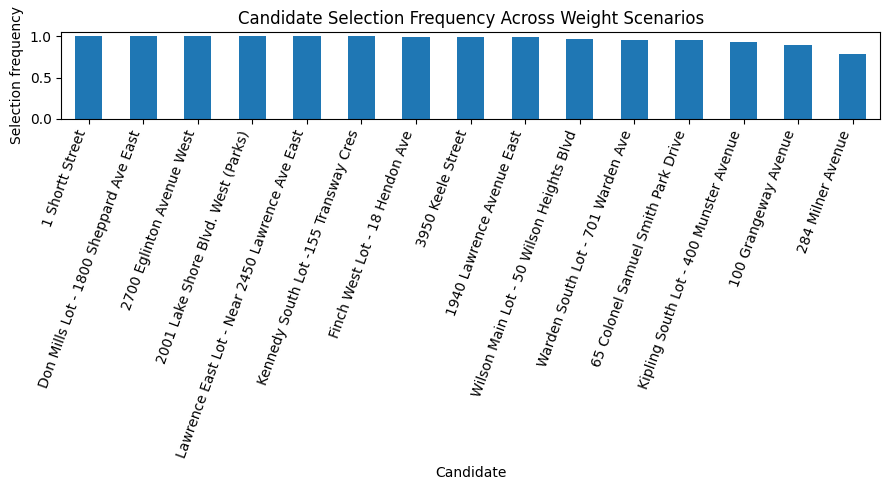

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))

sensitivity_table.head(15).plot(
    x="address",
    y="selection_frequency",
    kind="bar",
    legend=False,
    ax=ax,
)

ax.set_title(
    "Candidate Selection Frequency Across Weight Scenarios"
)
ax.set_xlabel("Candidate")
ax.set_ylabel("Selection frequency")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()



### Key candidate fields

| Field | Interpretation |
|---|---|
| `candidate_id` | Stable Green P/TTC candidate identifier |
| `capacity_filled` | Observed or median-imputed parking capacity |
| `capacity_missing` | Indicates whether original capacity was missing |
| `distance_to_nearest_charger_m` | Distance to known charging supply |
| `existing_chargers_1000m` / `2000m` | Existing supply counts |
| `population_1000m` | Area-weighted population estimate |
| `apartment_share_1000m` | Estimated apartment-population share |
| `traffic_volume_weighted_1000m` | Distance-weighted nearby traffic |
| `traffic_data_quality` | Quality class based on nearest counter distance |
| `distance_to_transit_stop_m` | Distance to nearest unique TTC stop location |
| `destination_count_1000m` | Number of public destinations within 1 km |
| `demand_score` | Combined population, traffic, and apartment score |
| `coverage_score` | Combined distance and existing-supply score |
| `accessibility_score` | Combined arterial, transit, and intersection score |
| `feasibility_score` | Parking-capacity/facility proxy |
| `equity_score` | Underserved-population and apartment-access score |
| `overall_score` | Balanced deterministic suitability score |
| `selection_round` | Order in the sequential recommendation |
| `selection_score` | Dynamic score at the time the site was selected |
| `marginal_population` | Newly covered population in the population-aware run |



## 23. Export compact agent-ready results

The final section saves compact analytical products for mapping, review, and a
future LlamaIndex agent layer.

### Exported files

| File | Purpose |
|---|---|
| `outputs/agent_candidate_summary.json` | Compact candidate evidence and category scores |
| `outputs/selected_site_sequence.csv` | Ordered recommendation sequence |
| `data/processed/scored_ev_charging_candidates.geojson` | All eligible scored candidates |
| `data/processed/selected_ev_charging_sites.geojson` | Final recommended locations |
| `outputs/planning_configuration.json` | Reproducible parameters and weights |

The export code converts categorical, string-extension, datetime, and nested
object values into GeoJSON-safe representations.

### Why compact exports matter

Future agents should receive concise evidence such as candidate scores,
distances, quality flags, and selection outcomes. They should not receive raw
traffic records, complete road networks, or Census polygons. This separation
reduces prompt size and prevents the language model from replacing verified GIS
calculations with unsupported spatial reasoning.


In [33]:

AGENT_CANDIDATE_COLUMNS = [
    "candidate_id",
    "address",
    "capacity_filled",
    "population_1000m",
    "traffic_volume_weighted_1000m",
    "distance_to_nearest_charger_m",
    "existing_chargers_2000m",
    "demand_score",
    "coverage_score",
    "accessibility_score",
    "feasibility_score",
    "equity_score",
    "overall_score",
    "traffic_data_quality",
    "capacity_missing",
]

available_agent_columns = [
    column
    for column in AGENT_CANDIDATE_COLUMNS
    if column in candidate_sites.columns
]

agent_candidate_summary = (
    candidate_sites[
        available_agent_columns
    ]
    .sort_values(
        "overall_score",
        ascending=False,
    )
    .copy()
)

# Convert pandas extension/categorical types to plain values.
for column in agent_candidate_summary.columns:
    if (
        isinstance(
            agent_candidate_summary[column].dtype,
            pd.CategoricalDtype,
        )
        or str(
            agent_candidate_summary[column].dtype
        ).startswith("string")
    ):
        agent_candidate_summary[column] = (
            agent_candidate_summary[column]
            .astype(object)
            .where(
                agent_candidate_summary[column].notna(),
                None,
            )
        )

agent_candidate_path = (
    OUTPUT_DIR
    / "agent_candidate_summary.json"
)

agent_candidate_summary.to_json(
    agent_candidate_path,
    orient="records",
    indent=2,
)

selected_export_columns = [
    column
    for column in [
        "selection_round",
        "candidate_id",
        "address",
        "selection_score",
        "marginal_population",
        "capacity_filled",
        "dynamic_distance_to_supply_m",
        "_distance",
        "overall_score",
    ]
    if column in final_selected_sites.columns
]

selected_sequence_path = (
    OUTPUT_DIR
    / "selected_site_sequence.csv"
)

final_selected_sites[
    selected_export_columns
].to_csv(
    selected_sequence_path,
    index=False,
)


def prepare_geojson_export(gdf):
    export = gdf.copy()

    for column in export.columns:
        if column == export.geometry.name:
            continue

        dtype_text = str(export[column].dtype)

        if (
            isinstance(
                export[column].dtype,
                pd.CategoricalDtype,
            )
            or dtype_text.startswith("string")
        ):
            export[column] = export[column].astype(str)

        elif pd.api.types.is_datetime64_any_dtype(
            export[column]
        ):
            export[column] = export[column].astype(str)

        elif export[column].dtype == "object":
            export[column] = export[column].map(
                lambda value: (
                    json.dumps(value)
                    if isinstance(
                        value,
                        (dict, list, tuple, set),
                    )
                    else value
                )
            )

    return export


candidate_geojson_path = (
    PROCESSED_DATA_DIR
    / "scored_ev_charging_candidates.geojson"
)

prepare_geojson_export(
    candidate_sites.to_crs(
        CONFIG["display_crs"]
    )
).to_file(
    candidate_geojson_path,
    driver="GeoJSON",
)

selected_geojson_path = (
    PROCESSED_DATA_DIR
    / "selected_ev_charging_sites.geojson"
)

prepare_geojson_export(
    final_selected_sites.to_crs(
        CONFIG["display_crs"]
    )
).to_file(
    selected_geojson_path,
    driver="GeoJSON",
)

configuration_path = (
    OUTPUT_DIR
    / "planning_configuration.json"
)

with open(
    configuration_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        CONFIG,
        file,
        indent=2,
    )

print(
    "Agent candidate summary:",
    agent_candidate_path.resolve(),
)
print(
    "Selected sequence:",
    selected_sequence_path.resolve(),
)
print(
    "Candidate GeoJSON:",
    candidate_geojson_path.resolve(),
)
print(
    "Selected GeoJSON:",
    selected_geojson_path.resolve(),
)
print(
    "Configuration:",
    configuration_path.resolve(),
)

scenario_table.to_csv(
    OUTPUT_DIR / "scenario_results.csv",
    index=False,
)

sensitivity_table.to_csv(
    OUTPUT_DIR / "sensitivity_results.csv",
    index=False,
)


Agent candidate summary: /Users/miladsaeedi/Desktop/Daily_Work_load/Projects_for_CV/Geospatial_site_selection/outputs/agent_candidate_summary.json
Selected sequence: /Users/miladsaeedi/Desktop/Daily_Work_load/Projects_for_CV/Geospatial_site_selection/outputs/selected_site_sequence.csv
Candidate GeoJSON: /Users/miladsaeedi/Desktop/Daily_Work_load/Projects_for_CV/Geospatial_site_selection/data/processed/scored_ev_charging_candidates.geojson
Selected GeoJSON: /Users/miladsaeedi/Desktop/Daily_Work_load/Projects_for_CV/Geospatial_site_selection/data/processed/selected_ev_charging_sites.geojson
Configuration: /Users/miladsaeedi/Desktop/Daily_Work_load/Projects_for_CV/Geospatial_site_selection/outputs/planning_configuration.json



# Deterministic stage complete

At this point, the notebook has produced:

- a cleaned known-charger network;
- an eligible parking-facility candidate set;
- population, household, apartment, traffic, transit, destination, and optional
  road indicators;
- transparent demand, coverage, accessibility, feasibility, and equity scores;
- a deterministic static ranking;
- spatially distributed sequential recommendations;
- population-aware marginal-coverage recommendations;
- policy-scenario and weight-sensitivity results;
- comparisons with simpler baselines;
- an interactive map and machine-readable exports.

## Current methodological limitations

1. **Candidate scope:** only Green P and TTC parking facilities are considered.
2. **Charger completeness:** without the optional supplemental file, supply is
   limited to the City-operated dataset.
3. **Temporal consistency:** Census, traffic, parking, GTFS, and charger data may
   represent different dates.
4. **Traffic interpretation:** turning-movement counts are spatial demand
   proxies and may not represent annual average traffic.
5. **Apartment estimate:** apartment population is an approximation created in
   preprocessing.
6. **Road access:** OSM road proximity does not confirm legal or physical site
   access.
7. **Service distance:** Euclidean buffers are used instead of road-network
   travel distance.
8. **Population coverage:** marginal coverage uses dissemination-area
   centroids.
9. **Feasibility:** electrical capacity, construction cost, land ownership,
   permits, charger power, accessibility design, and utility upgrades are not
   modelled.
10. **Subjective weights:** scenario and sensitivity analysis improve
    transparency but do not eliminate policy judgment.

## Next agentic stage

The next phase can wrap the deterministic outputs as tools and introduce
specialized agents, for example:

- **Demand Agent:** interprets population and traffic evidence;
- **Coverage Agent:** explains service gaps and network expansion;
- **Accessibility Agent:** reviews roads, transit, and destinations;
- **Feasibility Agent:** flags capacity and implementation concerns;
- **Equity Agent:** explains geographic-access implications;
- **Reviewer Agent:** challenges assumptions and checks consistency;
- **Coordinator Agent:** combines the evidence into a final planning memo.

Agents should cite the exported evidence and must not recalculate raw spatial
relationships in natural language.
